# Article-Style Reproduction Pipeline (Single Notebook)

This notebook does everything in one place:
1. Paper-style tweet preprocessing (POS/NEG binary setup)
2. ML training + evaluation + visualization
3. Deep learning training (CNN + BiLSTM) + visualization
4. Export a standalone `GridSearchCV` script at the end

In [1]:
import re
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

In [2]:
# --- Paper-style preprocessing (compact version) ---
# Aligned with article style: remove RT, URLs, mentions, hashtags, punctuation,
# normalize Arabic forms, remove elongation/diacritics, optional stopwords.

RT_RE = re.compile(r"(?i)(^|\s)(RT|رتويت)(\s+|:|\b)")
URL_RE = re.compile(r"http\S+|www\.\S+")
MENTION_RE = re.compile(r"@\S+")
HASHTAG_RE = re.compile(r"#\S+")
DIAC_RE = re.compile(r"[\u0617-\u061A\u064B-\u0652]")
TATWEEL_RE = re.compile(r"\u0640")
REPEAT_RE = re.compile(r"(.)\1{2,}")
NON_AR_RE = re.compile(r"[^\u0600-\u06FF\s]")
SPACE_RE = re.compile(r"\s+")

# small built-in stopword seed; replace with larger list if you have one
STOPWORDS = {
    "في","من","الى","إلى","على","عن","أن","ان","و","ف","ب","ك","ل","ما","هذا","هذه","ذلك","تلك",
    "كان","كانت","قد","ثم","او","أو","لكن","هنا","هناك","عند","بين","بعد","قبل","فى","الا","إلا"
}
# keep negations (important for sentiment)
for keep in ["لا", "ليس", "مش", "مو", "لم", "لن"]:
    STOPWORDS.discard(keep)

NORM_MAP = str.maketrans({
    "أ": "ا", "إ": "ا", "آ": "ا",
    "ة": "ه", "ى": "ي", "ؤ": "و", "ئ": "ي"
})

EMO_POS = {"😀","😁","😂","🤣","😊","😍","❤","❤️","👍","👏","🥰","😎"}
EMO_NEG = {"😡","😠","😢","😭","👎","💔","😞","😣","😖","🤮"}

def map_emoji_to_ar_tokens(text: str) -> str:
    out = []
    for ch in text:
        if ch in EMO_POS:
            out.append(" سمايلي_موجب ")
        elif ch in EMO_NEG:
            out.append(" سمايلي_سلبي ")
        else:
            out.append(ch)
    return "".join(out)


def preprocess_tweet_article_style(text: str, use_stopwords: bool = True) -> str:
    t = RT_RE.sub(" ", text)
    t = URL_RE.sub(" ", t)
    t = MENTION_RE.sub(" ", t)
    t = HASHTAG_RE.sub(" ", t)  # paper style removes full hashtag tokens
    t = map_emoji_to_ar_tokens(t)
    t = t.translate(NORM_MAP)
    t = DIAC_RE.sub("", t)
    t = TATWEEL_RE.sub("", t)
    t = REPEAT_RE.sub(r"\1", t)
    t = NON_AR_RE.sub(" ", t)
    t = SPACE_RE.sub(" ", t).strip()
    if use_stopwords and t:
        t = " ".join(w for w in t.split() if w not in STOPWORDS)
    return t

In [5]:
# --- Load ASTD-like Tweets file and build binary balanced dataset ---

data_path = Path("../ASTD/data/Tweets.txt")
if not data_path.exists():
    data_path = Path("../data/Tweets.txt")

rows = []
for line in data_path.read_text(encoding="utf-8").splitlines():
    line = line.strip()
    if not line or "\t" not in line:
        continue
    text, label = line.rsplit("\t", 1)
    label = label.strip().upper()
    rows.append((text.strip(), label))

df = pd.DataFrame(rows, columns=["text", "label"])
print("All labels:", df["label"].value_counts().to_dict())

# binary setup (paper style): POS/NEG only, balanced
# NOTE: avoid ``groupby(...).apply(sample)`` on recent pandas — it can drop the
# grouping column ``label`` from the result, causing KeyError. Use concat instead.
bin_df = df[df["label"].isin(["POS", "NEG"])].copy()
vc = bin_df["label"].value_counts()
min_n = int(vc.min())
pos = bin_df[bin_df["label"] == "POS"].sample(min_n, random_state=SEED)
neg = bin_df[bin_df["label"] == "NEG"].sample(min_n, random_state=SEED)
bin_df = (
    pd.concat([pos, neg], ignore_index=True)
    .sample(frac=1.0, random_state=SEED)
    .reset_index(drop=True)
)

bin_df["clean_text"] = bin_df["text"].apply(preprocess_tweet_article_style)
bin_df = bin_df[bin_df["clean_text"].str.strip().ne("")].reset_index(drop=True)

print("Binary balanced size:", len(bin_df))
print(bin_df["label"].value_counts().to_dict())
bin_df.head(3)

All labels: {'OBJ': 6691, 'NEG': 1684, 'NEUTRAL': 832, 'POS': 799}
Binary balanced size: 1568
{'NEG': 788, 'POS': 780}


,text,label,clean_text
0,الوطن | العزل والرئاسة | عمرو حمزاوي:,NEG,الوطن العزل والرياسه عمرو حمزاوي
1,الحمد لله ان حقن دماء المصريين وأصلح بينهم وعق...,POS,الحمد لله حقن دماء المصريين واصلح بينهم وعقبال...
2,#حركة_كايدينهم #مصر #قول_كلمه_للسيسي_وخد_فولو_...,POS,ياسيسي يا اصيل


In [6]:
# quick transformation examples
sample = bin_df.sample(3, random_state=SEED)[["text", "clean_text", "label"]]
sample

,text,clean_text,label
1535,صدق من قال لاتستطيع شراء الاخوان لانهم قوم لاس...,صدق قال لاتستطيع شراء الاخوان لانهم قوم لاسعر ...,POS
983,واحد بيطبل بقاله 3 سنين وفي الأخر مش عايزينه ي...,واحد بيطبل بقاله سنين وفي الاخر مش عايزينه يبق...,NEG
432,رحم الله الحاضر الغائب أيقونة النضال الفلسطينى...,رحم الله الحاضر الغايب ايقونه النضال الفلسطيني...,POS


In [7]:
# train/test split
X = bin_df["clean_text"].astype(str).tolist()
y = (bin_df["label"] == "POS").astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

len(X_train), len(X_test)

(1254, 314)

In [8]:
# --- ML training ---
vectorizer = TfidfVectorizer(
    lowercase=False,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=30000,
    sublinear_tf=True,
    norm="l2",
)

Xtr_tfidf = vectorizer.fit_transform(X_train)
Xte_tfidf = vectorizer.transform(X_test)

ml_models = {
    "LinearSVC": LinearSVC(C=1.0, max_iter=10000, dual=False),
    "LogReg": LogisticRegression(max_iter=5000),
    "MNB": MultinomialNB(),
}

ml_rows = []
trained_ml = {}
for name, model in ml_models.items():
    model.fit(Xtr_tfidf, y_train)
    pred = model.predict(Xte_tfidf)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    ml_rows.append({"model": name, "accuracy": acc, "f1": f1})
    trained_ml[name] = model

ml_results = pd.DataFrame(ml_rows).sort_values("f1", ascending=False).reset_index(drop=True)
ml_results

,model,accuracy,f1
0,LinearSVC,0.691083,0.688103
1,MNB,0.707006,0.682759
2,LogReg,0.681529,0.671053


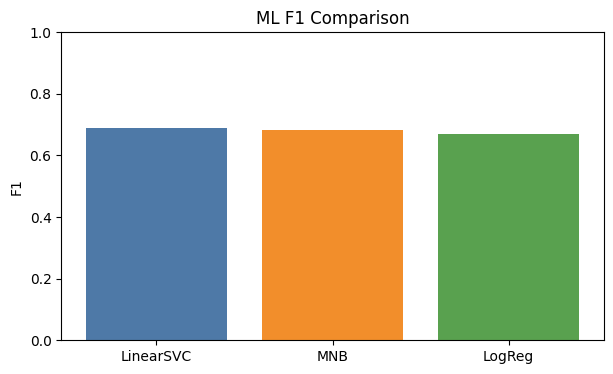

Best ML model: LinearSVC
              precision    recall  f1-score   support

           0     0.6918    0.6962    0.6940       158
           1     0.6903    0.6859    0.6881       156

    accuracy                         0.6911       314
   macro avg     0.6911    0.6910    0.6911       314
weighted avg     0.6911    0.6911    0.6911       314



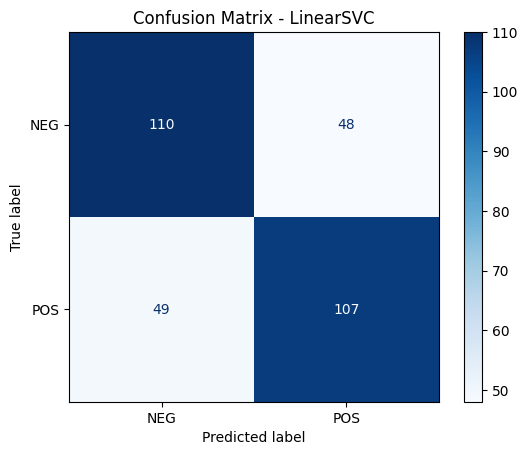

In [9]:
# --- ML visualization ---
plt.figure(figsize=(7,4))
plt.bar(ml_results["model"], ml_results["f1"], color=["#4e79a7", "#f28e2b", "#59a14f"])
plt.ylim(0,1)
plt.title("ML F1 Comparison")
plt.ylabel("F1")
plt.show()

best_ml_name = ml_results.iloc[0]["model"]
best_ml = trained_ml[best_ml_name]
best_pred = best_ml.predict(Xte_tfidf)

print(f"Best ML model: {best_ml_name}")
print(classification_report(y_test, best_pred, digits=4))

cm = confusion_matrix(y_test, best_pred)
ConfusionMatrixDisplay(cm, display_labels=["NEG","POS"]).plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_ml_name}")
plt.show()

In [10]:
# --- Deep Learning (CNN + BiLSTM, Keras) ---
# If tensorflow is not installed in this kernel, install/select the right environment first.

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, LSTM, Bidirectional, Dense, Dropout

MAX_WORDS = 30000
MAX_LEN = 120
EMB_DIM = 128

tok = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tok.fit_on_texts(X_train)

Xtr_seq = pad_sequences(tok.texts_to_sequences(X_train), maxlen=MAX_LEN, padding="post", truncating="post")
Xte_seq = pad_sequences(tok.texts_to_sequences(X_test), maxlen=MAX_LEN, padding="post", truncating="post")

cnn = Sequential([
    Embedding(MAX_WORDS, EMB_DIM, input_length=MAX_LEN),
    Conv1D(128, 5, activation="relu"),
    GlobalMaxPooling1D(),
    Dropout(0.3),
    Dense(1, activation="sigmoid"),
])
cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

bilstm = Sequential([
    Embedding(MAX_WORDS, EMB_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(1, activation="sigmoid"),
])
bilstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

hist_cnn = cnn.fit(Xtr_seq, y_train, validation_split=0.1, epochs=5, batch_size=64, verbose=1)
hist_bi = bilstm.fit(Xtr_seq, y_train, validation_split=0.1, epochs=5, batch_size=64, verbose=1)

cnn_pred = (cnn.predict(Xte_seq, verbose=0).ravel() >= 0.5).astype(int)
bi_pred = (bilstm.predict(Xte_seq, verbose=0).ravel() >= 0.5).astype(int)

dl_results = pd.DataFrame([
    {"model": "CNN", "accuracy": accuracy_score(y_test, cnn_pred), "f1": f1_score(y_test, cnn_pred)},
    {"model": "BiLSTM", "accuracy": accuracy_score(y_test, bi_pred), "f1": f1_score(y_test, bi_pred)},
])
dl_results

c:\Users\pc\Desktop\Projects\Natural-Lang-Processing-Arabic\arabic-sentiment-analysis\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.5532 - loss: 0.6857 - val_accuracy: 0.6429 - val_loss: 0.6765
Epoch 2/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.7553 - loss: 0.6306 - val_accuracy: 0.6111 - val_loss: 0.6660
Epoch 3/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9158 - loss: 0.5465 - val_accuracy: 0.6667 - val_loss: 0.6421
Epoch 4/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9628 - loss: 0.3902 - val_accuracy: 0.6825 - val_loss: 0.6114
Epoch 5/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9770 - loss: 0.1928 - val_accuracy: 0.6746 - val_loss: 0.6285
Epoch 1/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - accuracy: 0.5488 - loss: 0.6897 - val_accuracy: 0.6032 - val_loss: 0.6784
Epoch 2/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.6755 - loss: 0.6468 - val_accuracy: 0.6508 - val_loss: 0.6461
Epoch 3/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.8129 - loss: 0.4947 - val_accuracy: 0.6429 - val_lo

,model,accuracy,f1
0,CNN,0.691083,0.688103
1,BiLSTM,0.608280,0.616822


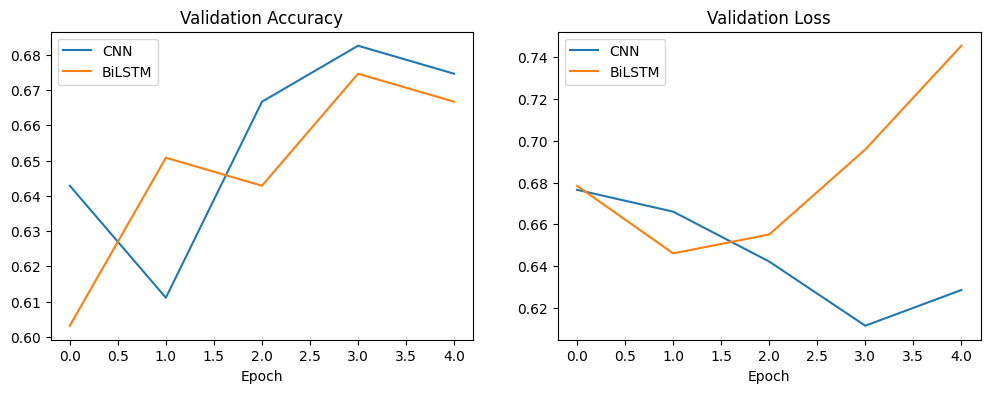

CNN report
              precision    recall  f1-score   support

           0     0.6918    0.6962    0.6940       158
           1     0.6903    0.6859    0.6881       156

    accuracy                         0.6911       314
   macro avg     0.6911    0.6910    0.6911       314
weighted avg     0.6911    0.6911    0.6911       314

BiLSTM report
              precision    recall  f1-score   support

           0     0.6174    0.5823    0.5993       158
           1     0.6000    0.6346    0.6168       156

    accuracy                         0.6083       314
   macro avg     0.6087    0.6084    0.6081       314
weighted avg     0.6088    0.6083    0.6080       314



In [11]:
# --- Deep learning visualization ---
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(hist_cnn.history["val_accuracy"], label="CNN")
axes[0].plot(hist_bi.history["val_accuracy"], label="BiLSTM")
axes[0].set_title("Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(hist_cnn.history["val_loss"], label="CNN")
axes[1].plot(hist_bi.history["val_loss"], label="BiLSTM")
axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.show()

print("CNN report")
print(classification_report(y_test, cnn_pred, digits=4))
print("BiLSTM report")
print(classification_report(y_test, bi_pred, digits=4))

In [12]:
# --- Final comparison (ML + DL) ---
all_results = pd.concat([
    ml_results[["model", "accuracy", "f1"]],
    dl_results[["model", "accuracy", "f1"]]
], ignore_index=True).sort_values("f1", ascending=False)

all_results

,model,accuracy,f1
0,LinearSVC,0.691083,0.688103
3,CNN,0.691083,0.688103
1,MNB,0.707006,0.682759
2,LogReg,0.681529,0.671053
4,BiLSTM,0.608280,0.616822


In [ ]:
# --- Export a standalone GridSearchCV script (as requested) ---
script = r'''from pathlib import Path
import re
import random
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

SEED = 42
random.seed(SEED)

RT_RE = re.compile(r"(?i)(^|\s)(RT|رتويت)(\s+|:|\b)")
URL_RE = re.compile(r"http\S+|www\.\S+")
MENTION_RE = re.compile(r"@\S+")
HASHTAG_RE = re.compile(r"#\S+")
DIAC_RE = re.compile(r"[\u0617-\u061A\u064B-\u0652]")
TATWEEL_RE = re.compile(r"\u0640")
REPEAT_RE = re.compile(r"(.)\1{2,}")
NON_AR_RE = re.compile(r"[^\u0600-\u06FF\s]")
SPACE_RE = re.compile(r"\s+")
NORM_MAP = str.maketrans({"أ":"ا","إ":"ا","آ":"ا","ة":"ه","ى":"ي","ؤ":"و","ئ":"ي"})

def prep(t: str) -> str:
    t = RT_RE.sub(" ", t)
    t = URL_RE.sub(" ", t)
    t = MENTION_RE.sub(" ", t)
    t = HASHTAG_RE.sub(" ", t)
    t = t.translate(NORM_MAP)
    t = DIAC_RE.sub("", t)
    t = TATWEEL_RE.sub("", t)
    t = REPEAT_RE.sub(r"\\1", t)
    t = NON_AR_RE.sub(" ", t)
    t = SPACE_RE.sub(" ", t).strip()
    return t

p = Path("ASTD/data/Tweets.txt")
if not p.exists():
    p = Path("data/Tweets.txt")

rows = []
for line in p.read_text(encoding="utf-8").splitlines():
    line = line.strip()
    if not line or "\t" not in line:
        continue
    txt, lab = line.rsplit("\t", 1)
    lab = lab.strip().upper()
    if lab in {"POS", "NEG"}:
        rows.append((prep(txt.strip()), 1 if lab == "POS" else 0))

df = pd.DataFrame(rows, columns=["x", "y"])
min_n = df["y"].value_counts().min()
df = df.groupby("y", group_keys=False).apply(lambda g: g.sample(min_n, random_state=SEED)).sample(frac=1, random_state=SEED)

X_train, X_test, y_train, y_test = train_test_split(df["x"], df["y"], test_size=0.2, random_state=SEED, stratify=df["y"])

pipe = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=False, ngram_range=(1,2), min_df=2, max_df=0.95, sublinear_tf=True, norm="l2")),
    ("clf", LinearSVC(max_iter=10000, dual=False)),
])

grid = GridSearchCV(pipe, {"clf__C":[0.1, 0.5, 1, 10, 100]}, cv=5, scoring="f1", n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)
pred = grid.predict(X_test)

print("Best params:", grid.best_params_)
print("Accuracy:", round(accuracy_score(y_test, pred), 4))
print(classification_report(y_test, pred, digits=4))
'''

Path("../scripts").mkdir(parents=True, exist_ok=True)
Path("../scripts/gridsearch_article_style.py").write_text(script, encoding="utf-8")
print("saved -> ../scripts/gridsearch_article_style.py")